# Prepare Dats for model training

We first need to:
1. Extract the joint angles and velocities from the raw data
2. Segment into Stance phase
3. Resample to 101 samples


In [1]:
from core.timeseries import get_group_curves, plot_group_curves, apply_continuous_curve_registration, plot_single_curves
from core.matlab_data_loader import MatlabDataLoader
from core.parallel_timeseries import compute_session_representation
from core.aggregators import MeanCurveAggregator, RegistrationCurveAggregator
import core.constants as c


from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp
from tqdm.notebook import tqdm


import warnings
import dtw as dtw
import kineticstoolkit as ktk
import numpy as np
import json
from pathlib import Path


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



Convergence after 10 iterations!


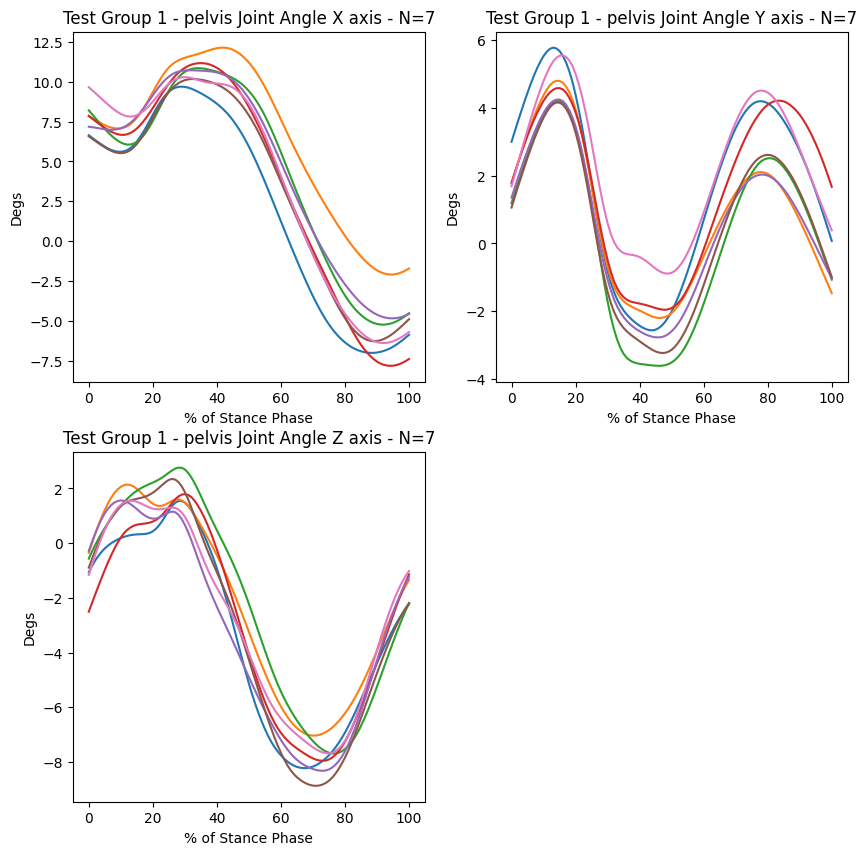

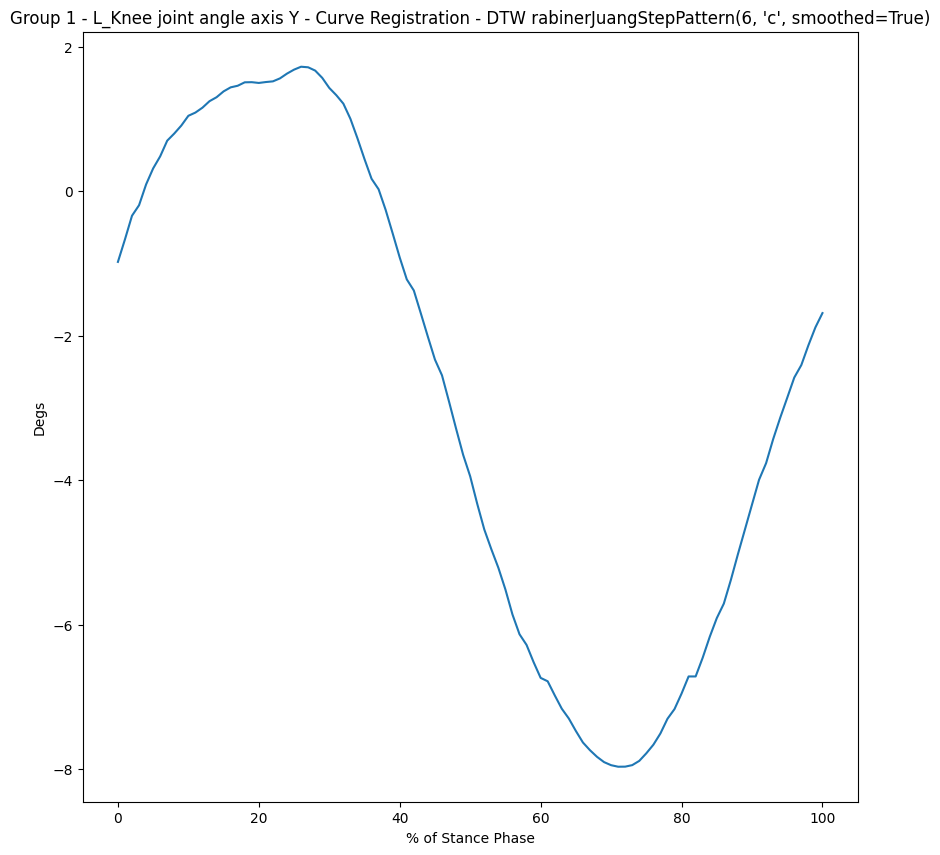

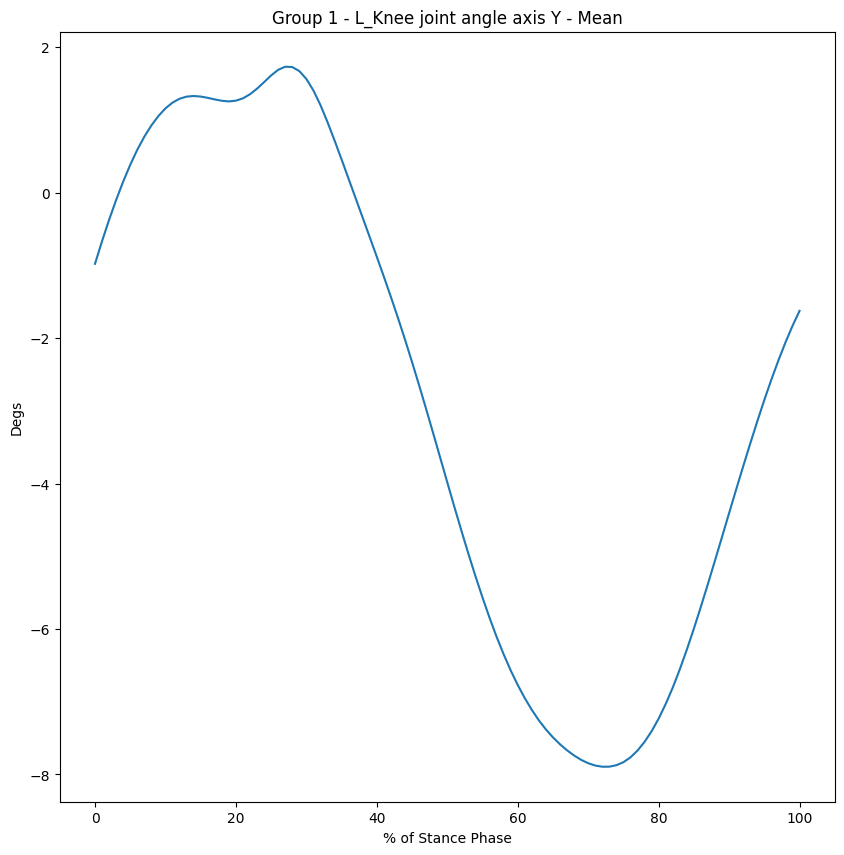

In [2]:
loader = MatlabDataLoader()

SAMPLE_JOINT = "pelvis"

one_session = loader.get_successful_sessions()[554]
one_session_ts = loader.get_joint_angles_timeseries(one_session, SAMPLE_JOINT, include_events=True)
test1_group = get_group_curves(one_session_ts)
plot_group_curves(test1_group, "Test Group 1", f"{SAMPLE_JOINT} Joint Angle", "Degs", "% of Stance Phase")

test1_group_z_axis = test1_group[:, :, 2]
re_test1_group_z_axis = apply_continuous_curve_registration(test1_group_z_axis, max_iter=10000,plot_type="twoway",step_pattern=dtw.rabinerJuangStepPattern(6, "c", smoothed=True))
plot_single_curves(re_test1_group_z_axis, "Group 1 - L_Knee joint angle axis Y - Curve Registration - DTW rabinerJuangStepPattern(6, 'c', smoothed=True)", "Degs", "% of Stance Phase")
plot_single_curves(test1_group_z_axis.mean(axis=0), "Group 1 - L_Knee joint angle axis Y - Mean", "Degs", "% of Stance Phase")


test1_group.shape

np.False_

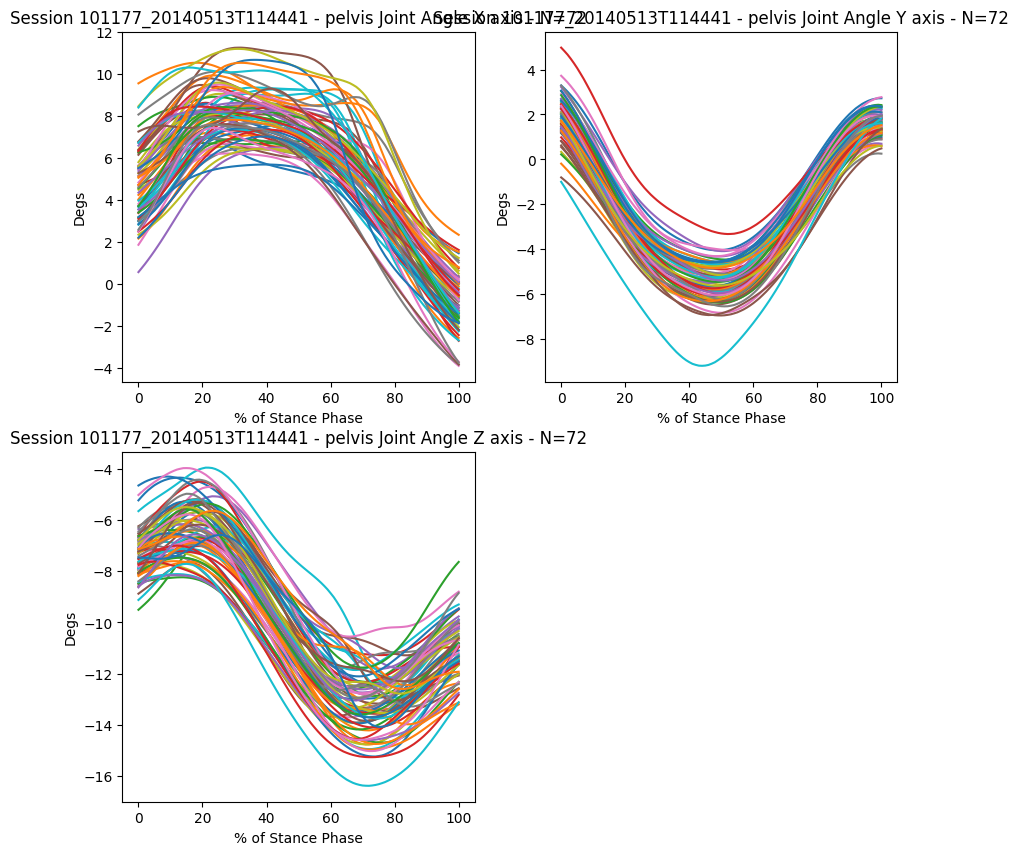

In [19]:
from core.outlier_detection import detect_temporal_anomalies
SAMPLE_JOINT = "pelvis"
# ANOMALY_SESSION = "100048_20110615T114931"

loader = MatlabDataLoader()
session = loader.get_successful_sessions()[1235]
session_ts = loader.get_joint_angles_timeseries(session, SAMPLE_JOINT, include_events=True)
session_group = get_group_curves(session_ts)
plot_group_curves(session_group, f"Session {session}", f"{SAMPLE_JOINT} Joint Angle", "Degs", "% of Stance Phase")

outliers = detect_temporal_anomalies(session_group)
outliers.any()



## Time to extract the time series data

RESULTS_DIR = Path(c.RICKD_PROCESSED_DATA_FOLDER) / 'timeseries'
RESULTS_DIR.mkdir(exist_ok=True, parents=True)

session_ids = loader.get_successful_sessions()
print(f"Total successful sessions: {len(session_ids)}")

joints =  ['L_ankle', 'L_foot', 'L_hip', 'L_knee', 'R_ankle', 'R_foot', 'R_hip', 'R_knee', 'pelvis']

# Build channel ordering: per joint → angle XYZ then velocity XYZ
channels = []
for j in joints:
    for comp in ['X','Y','Z']:
        channels.append(f"{j}_angle_{comp}")
    for comp in ['X','Y','Z']:
        channels.append(f"{j}_velocity_{comp}")

n_jobs = min(8, mp.cpu_count())
results_m = []
with ProcessPoolExecutor(max_workers=n_jobs) as ex:
    # Using the mean curve aggregator.
    futures = [ex.submit(compute_session_representation, sid, joints, MeanCurveAggregator()) for sid in session_ids]
    for f in tqdm(as_completed(futures), total=len(futures), desc=f"Processing sessions (process pool) - Num. Jobs: {n_jobs}"):
        r = f.result()
        if r is not None:
            results_m.append(r)

valid_session_ids_m, reps_m = zip(*results_m) if results_m else ([], [])
all_sessions_matrix_m = np.stack(reps_m, axis=0) if reps_m else np.zeros((0,101,0))
print(f"Matrix shape: {all_sessions_matrix_m.shape} (n_sessions, 101, {len(channels)})")

all_sessions_matrix_m

# Persist results (Mean variant)
np.save(RESULTS_DIR / 'timeseries_clean_mean_matrix.npy', all_sessions_matrix_m)
with open(RESULTS_DIR / 'timeseries_clean_mean_channels.json', 'w') as f:
    json.dump(channels, f, indent=2)
with open(RESULTS_DIR / 'timeseries_clean_mean_sessions.json', 'w') as f:
    json.dump(list(valid_session_ids_m), f, indent=2)